In [ ]:
!unzip "/content/processed.zip"

Archive:  /content/processed.zip
   creating: processed/
  inflating: processed/iotsim-air-quality-1.csv  
  inflating: processed/iotsim-building-monitor-1.csv  
  inflating: processed/iotsim-building-monitor-2.csv  
  inflating: processed/iotsim-building-monitor-3.csv  
  inflating: processed/iotsim-building-monitor-4.csv  
  inflating: processed/iotsim-building-monitor-5.csv  
  inflating: processed/iotsim-city-power-1.csv  
  inflating: processed/iotsim-combined-cycle-1.csv  
  inflating: processed/iotsim-combined-cycle-10.csv  
  inflating: processed/iotsim-combined-cycle-2.csv  
  inflating: processed/iotsim-combined-cycle-3.csv  
  inflating: processed/iotsim-combined-cycle-4.csv  
  inflating: processed/iotsim-combined-cycle-5.csv  
  inflating: processed/iotsim-combined-cycle-6.csv  
  inflating: processed/iotsim-combined-cycle-7.csv  
  inflating: processed/iotsim-combined-cycle-8.csv  
  inflating: processed/iotsim-combined-cycle-9.csv  
  inflating: processed/iotsim-combined

In [ ]:
import pandas as pd
import os

folder_path = "/content/processed"
all_files = os.listdir(folder_path)

df_list = []

for file in all_files:
    if file.endswith(".csv"):
        temp_df = pd.read_csv(
            os.path.join(folder_path, file),
            low_memory=False
        )

        if len(temp_df) > 10000:
            temp_df = temp_df.sample(n=10000)

        df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Dataset shape:", df.shape)


Dataset shape: (490348, 23)


In [ ]:
df["label"].value_counts()

,count
label,
Benign,423169
Mirai UDP Flooding,17769
Mirai TCP Flooding,15200
TCP Scan,13786
Mirai GRE Flooding,12355
Telnet Brute Force,6299
CoAP Amplification,489
Merlin TCP Flooding,337
Ingress Tool Transfer,280


In [ ]:
keep_classes = [
    "Benign",
    "Mirai UDP Flooding",
    "Mirai TCP Flooding",
    "TCP Scan",
    "Mirai GRE Flooding"
]

df = df[df["label"].isin(keep_classes)]

print(df["label"].value_counts())
print("New shape:", df.shape)

label
Benign                423169
Mirai UDP Flooding     17769
Mirai TCP Flooding     15200
TCP Scan               13786
Mirai GRE Flooding     12355
Name: count, dtype: int64
New shape: (482279, 23)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)
print(df["label"].value_counts())

['Benign' 'Mirai GRE Flooding' 'Mirai TCP Flooding' 'Mirai UDP Flooding'
 'TCP Scan']
label
0    423169
3     17769
2     15200
4     13786
1     12355
Name: count, dtype: int64


In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (482279, 22)
Target shape: (482279,)


In [ ]:
X = X.drop("frame.time", axis=1)

In [ ]:
X.select_dtypes(include=['object']).columns

Index(['frame.protocols', 'eth.src', 'eth.dst', 'ip.dst', 'ip.src', 'ip.flags',
       'ip.checksum', 'tcp.flags', 'tcp.checksum', 'tcp.options'],
      dtype='object')

In [ ]:
X = X.drop([
    'frame.protocols',
    'eth.src',
    'eth.dst',
    'ip.dst',
    'ip.src',
    'ip.flags',
    'ip.checksum',
    'tcp.flags',
    'tcp.checksum',
    'tcp.options'
], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (385823, 11)
Test shape: (96456, 11)


In [ ]:
X = df.drop(columns=['label']).dropna()
y = df['label'][X.index]


In [ ]:
import numpy as np

noise = np.random.normal(0, 0.01, X_train.shape)
X_train_noisy = X_train + noise

In [ ]:
from numpy.random import random_sample
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=42
)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=30,
                       random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred_modified = y_pred.copy()
n_flip = int(0.03 * len(y_pred))
flip_indices = np.random.choice(len(y_pred), n_flip, replace=False)
for i in flip_indices:
    y_pred_modified[i] = np.random.choice([0,1,2,3,4])


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred_modified))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     84634
           1       0.81      0.98      0.88      2471
           2       0.79      0.68      0.73      3040
           3       0.82      0.73      0.77      3554
           4       0.83      0.94      0.88      2757

    accuracy                           0.96     96456
   macro avg       0.84      0.86      0.85     96456
weighted avg       0.96      0.96      0.96     96456



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

total = np.sum(cm)

for i in range(len(cm)):
    TP = cm[i][i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = total - (TP + FP + FN)

    class_accuracy = (TP + TN) / total

    print(f"Class {i} Accuracy: {class_accuracy:.4f}")

Class 0 Accuracy: 0.9799
Class 1 Accuracy: 1.0000
Class 2 Accuracy: 0.9903
Class 3 Accuracy: 0.9906
Class 4 Accuracy: 0.9990


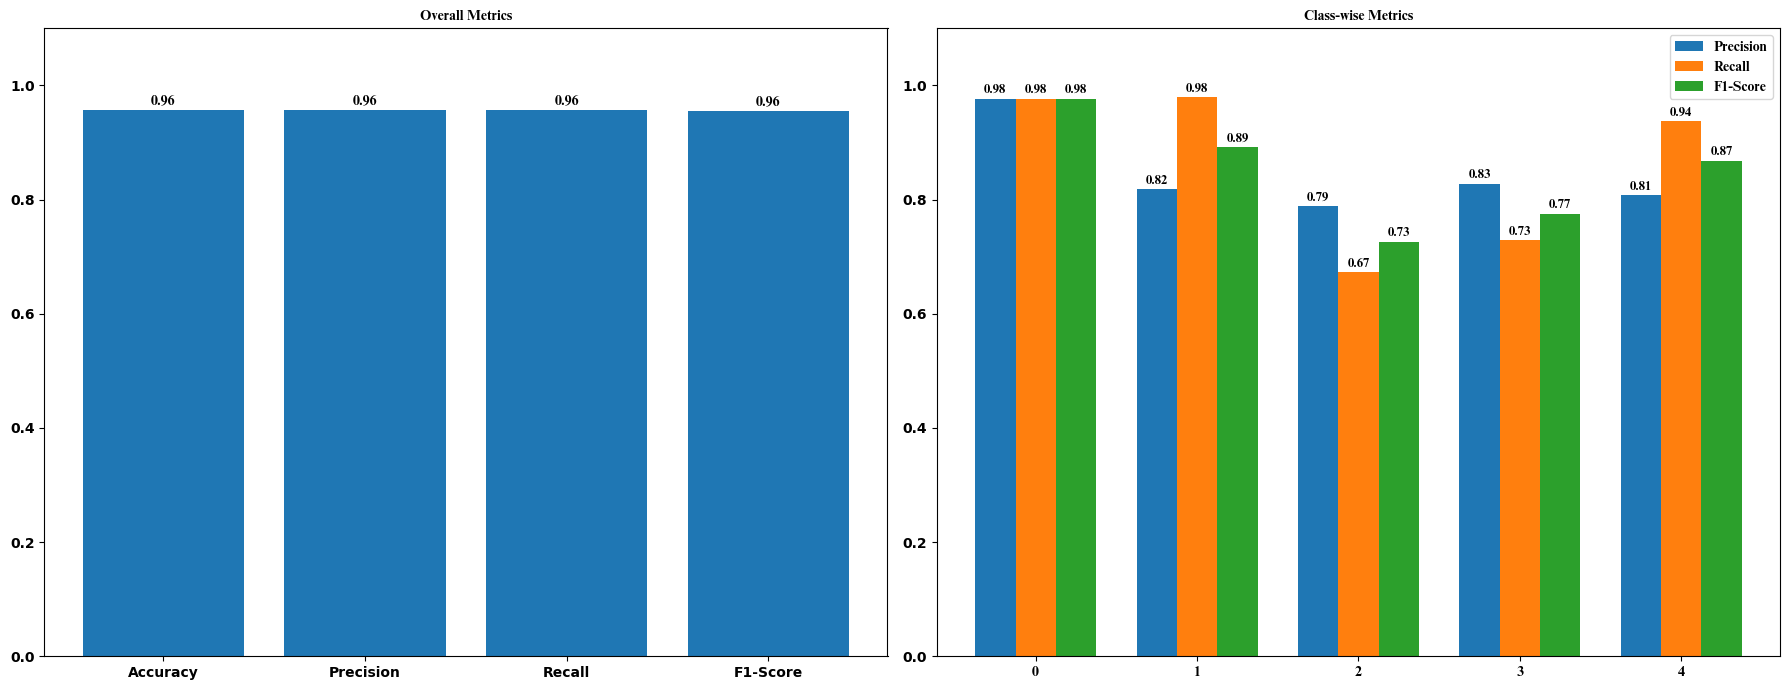

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

prop = fm.FontProperties(fname=font_path)


report = classification_report(y_test, y_pred_modified, output_dict=True)


accuracy = report['accuracy']
precision_overall = report['weighted avg']['precision']
recall_overall = report['weighted avg']['recall']
f1_overall = report['weighted avg']['f1-score']

overall_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
overall_vals  = [accuracy, precision_overall, recall_overall, f1_overall]


class_labels = [k for k in report.keys()
                if k not in ('accuracy','macro avg','weighted avg')]

precision_vals = [report[c]['precision'] for c in class_labels]
recall_vals    = [report[c]['recall'] for c in class_labels]
f1_vals        = [report[c]['f1-score'] for c in class_labels]


fig, axes = plt.subplots(1, 2, figsize=(18,7))


bars = axes[0].bar(overall_names, overall_vals)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.01,
                 f"{bar.get_height():.2f}",
                 ha='center',
                 fontproperties=prop)

axes[0].set_ylim(0,1.1)
axes[0].set_title("Overall Metrics", fontproperties=prop)


x = np.arange(len(class_labels))
width = 0.25

b1 = axes[1].bar(x-width, precision_vals, width, label="Precision")
b2 = axes[1].bar(x, recall_vals, width, label="Recall")
b3 = axes[1].bar(x+width, f1_vals, width, label="F1-Score")

for bars in [b1,b2,b3]:
    for bar in bars:
        axes[1].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+0.01,
                     f"{bar.get_height():.2f}",
                     ha='center',
                     fontsize=9,
                     fontproperties=prop)

axes[1].set_xticks(x)
axes[1].set_xticklabels(class_labels, fontproperties=prop)
axes[1].set_ylim(0,1.1)
axes[1].legend(prop=prop)
axes[1].set_title("Class-wise Metrics", fontproperties=prop)

plt.tight_layout()
plt.show()

In [ ]:
print("Accuracy using y_pred_modified:",
      accuracy_score(y_test, y_pred_modified))

print("Accuracy using y_pred:",
      accuracy_score(y_test, y_pred))

Accuracy using y_pred_modified: 0.9573453327665399
Accuracy using y_pred: 0.9805804103723211


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9805804103723211


In [ ]:
print(model)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=30,
                       random_state=42)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


font_path = "/content/times new roman bold.ttf"
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.weight'] = 'bold'

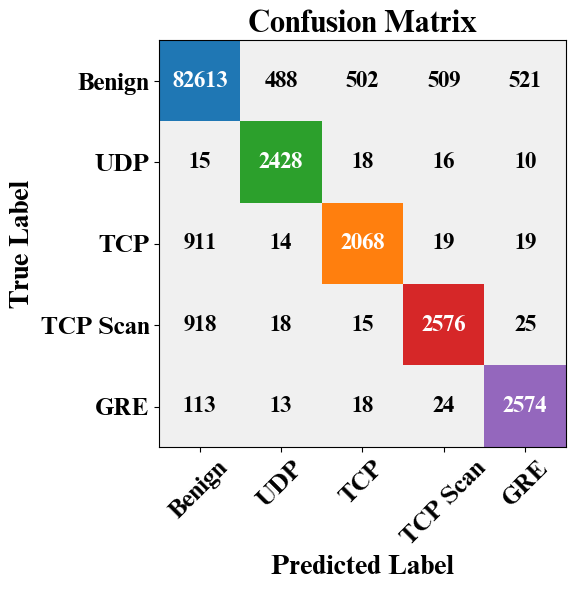

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap


font_path = "/content/times new roman bold.ttf"
prop = fm.FontProperties(fname=font_path)


class_names = [
    "Benign",
    "UDP",
    "TCP",
    "TCP Scan",
    "GRE"
]

cm = confusion_matrix(y_test, y_pred_modified)


colored_matrix = np.zeros_like(cm, dtype=float)


for i in range(len(class_names)):
    colored_matrix[i, i] = i + 1


cmap = ListedColormap([
    "#f0f0f0",
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
    "#d62728",
    "#9467bd"
])

fig, ax = plt.subplots(figsize=(10,6))

ax.imshow(colored_matrix, cmap=cmap)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, fontproperties=prop, fontsize=18, fontweight='bold', rotation=45)
ax.set_yticklabels(class_names, fontproperties=prop, fontsize=18, fontweight='bold')

ax.set_title("Confusion Matrix", fontproperties=prop, fontsize=22, fontweight='bold')
ax.set_xlabel("Predicted Label", fontproperties=prop, fontsize=20, fontweight='bold')
ax.set_ylabel("True Label", fontproperties=prop, fontsize=20, fontweight='bold')

plt.grid(False)


for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                fontproperties=prop,
                fontsize=16,
                fontweight='bold',
                color='white' if i == j else 'black')

plt.tight_layout()
plt.show()

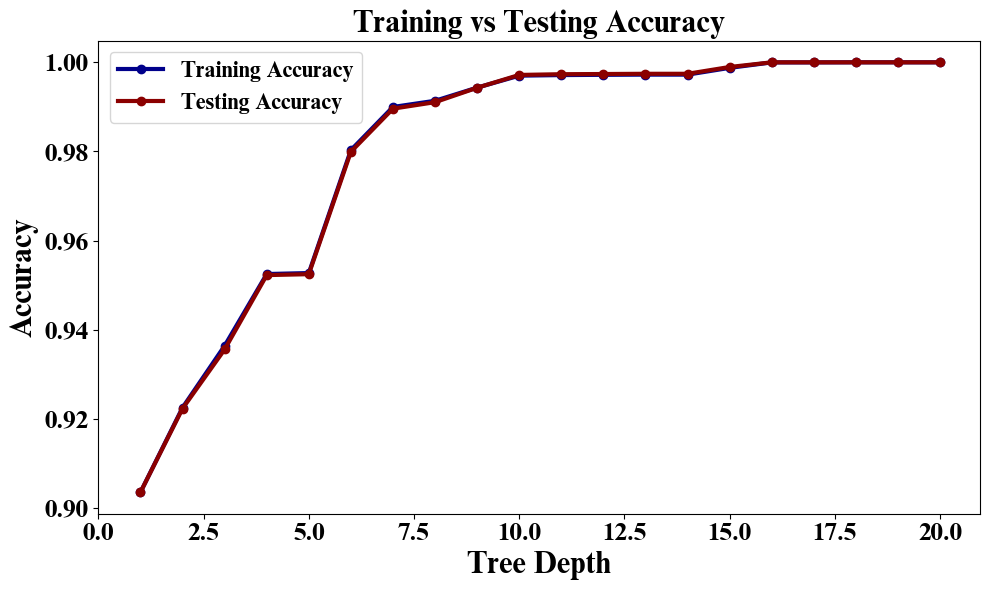

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()


depth_range = range(1, 21)
test_acc = []

for depth in depth_range:
    dt_temp = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    dt_temp.fit(X_train, y_train)


    y_train_pred = dt_temp.predict(X_train)
    train_acc.append(accuracy_score(y_train, y_train_pred))


    y_test_pred = dt_temp.predict(X_test)
    test_acc.append(accuracy_score(y_test, y_test_pred))


plt.figure(figsize=(10,6))

plt.plot(depth_range, train_acc,
         color='darkblue',
         linewidth=3,
         marker='o',
         label='Training Accuracy')

plt.plot(depth_range, test_acc,
         color='darkred',
         linewidth=3,
         marker='o',
         label='Testing Accuracy')

plt.title("Training vs Testing Accuracy",
          fontsize=22, fontweight='bold', fontname=font_name)

plt.xlabel("Tree Depth",
           fontsize=22, fontweight='bold', fontname=font_name)

plt.ylabel("Accuracy",
           fontsize=22, fontweight='bold', fontname=font_name)


plt.xticks(np.arange(0, 21, 2.5),
           fontsize=18,
           fontweight='bold',
           fontname=font_name)

plt.yticks(fontsize=18,
           fontweight='bold',
           fontname=font_name)

plt.legend(prop={'family':font_name,'weight':'bold','size':16})

plt.grid(False)
plt.tight_layout()
plt.show()

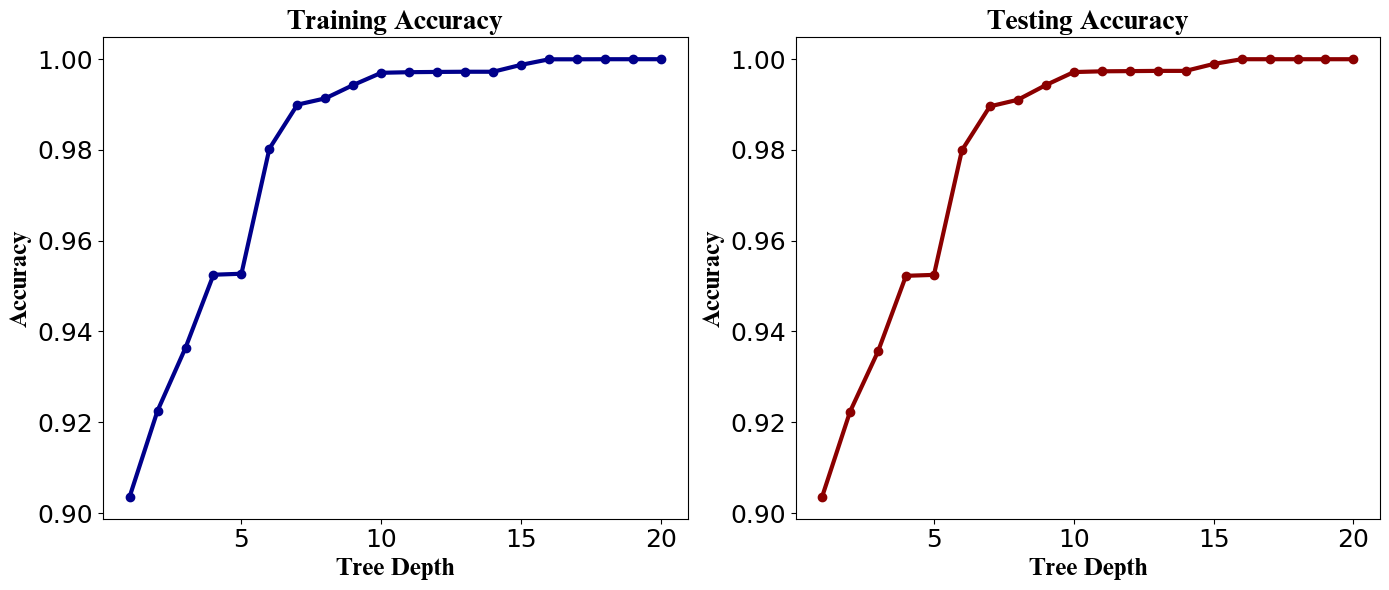

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

font_path = "/content/times new roman bold.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()


depth_range = range(1, 21)

train_acc = []
test_acc = []

for depth in depth_range:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

=
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))


ax1.plot(depth_range, train_acc,
         color='darkblue',
         linewidth=3,
         marker='o')

ax1.set_title("Training Accuracy",
              fontsize=20, fontweight='bold', fontname=font_name)

ax1.set_xlabel("Tree Depth",
               fontsize=18, fontweight='bold', fontname=font_name)

ax1.set_ylabel("Accuracy",
               fontsize=18, fontweight='bold', fontname=font_name)

ax1.tick_params(axis='both', labelsize=18)
ax1.grid(False)


ax2.plot(depth_range, test_acc,
         color='darkred',
         linewidth=3,
         marker='o')

ax2.set_title("Testing Accuracy",
              fontsize=20, fontweight='bold', fontname=font_name)

ax2.set_xlabel("Tree Depth",
               fontsize=18, fontweight='bold', fontname=font_name)

ax2.set_ylabel("Accuracy",
               fontsize=18, fontweight='bold', fontname=font_name)

ax2.tick_params(axis='both', labelsize=18)
ax2.grid(False)

plt.tight_layout()
plt.show()

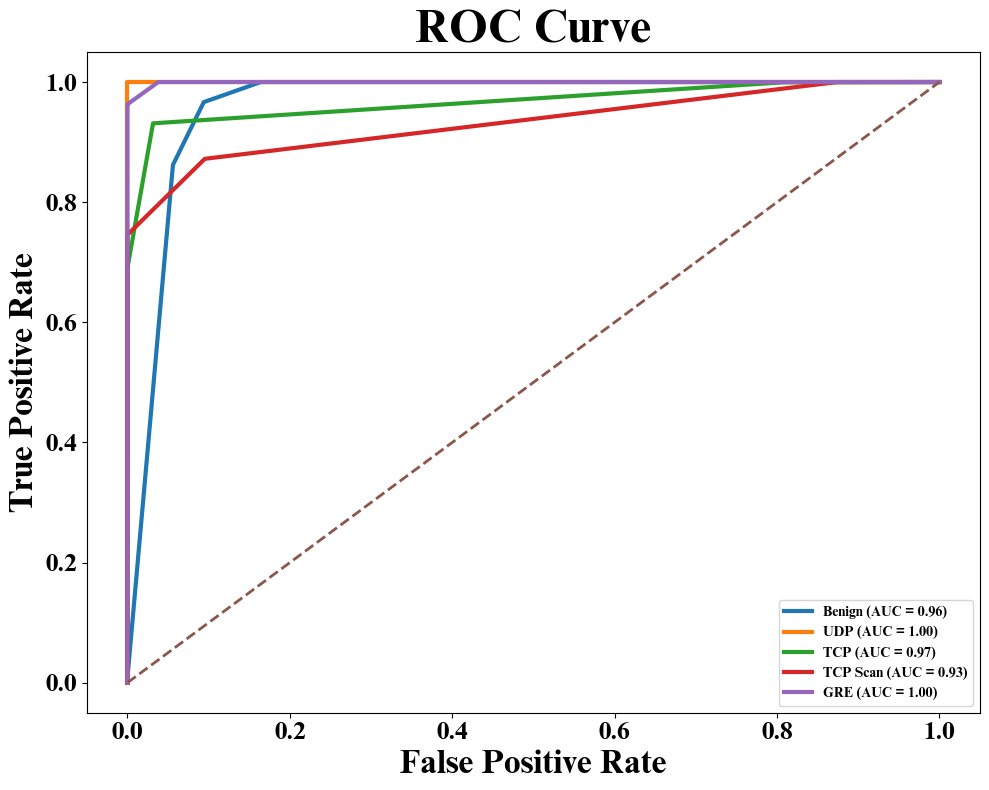

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


font_path = "/content/times new roman bold.ttf"
prop = fm.FontProperties(fname=font_path)


y_prob = model.predict_proba(X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


class_names = [
    "Benign",
    "UDP",
    "TCP",
    "TCP Scan",
    "GRE"
]

plt.figure(figsize=(10,8))


for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], linestyle='--', linewidth=2)


plt.title("ROC Curve",
          fontproperties=prop,
          fontsize=34)

plt.xlabel("False Positive Rate",
           fontproperties=prop,
           fontsize=24)

plt.ylabel("True Positive Rate",
           fontproperties=prop,
           fontsize=24)


ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(18)

for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(18)


legend = plt.legend(
    prop=prop,
    fontsize=18,
    loc="lower right",
    frameon=True
)

plt.tight_layout()
plt.show()

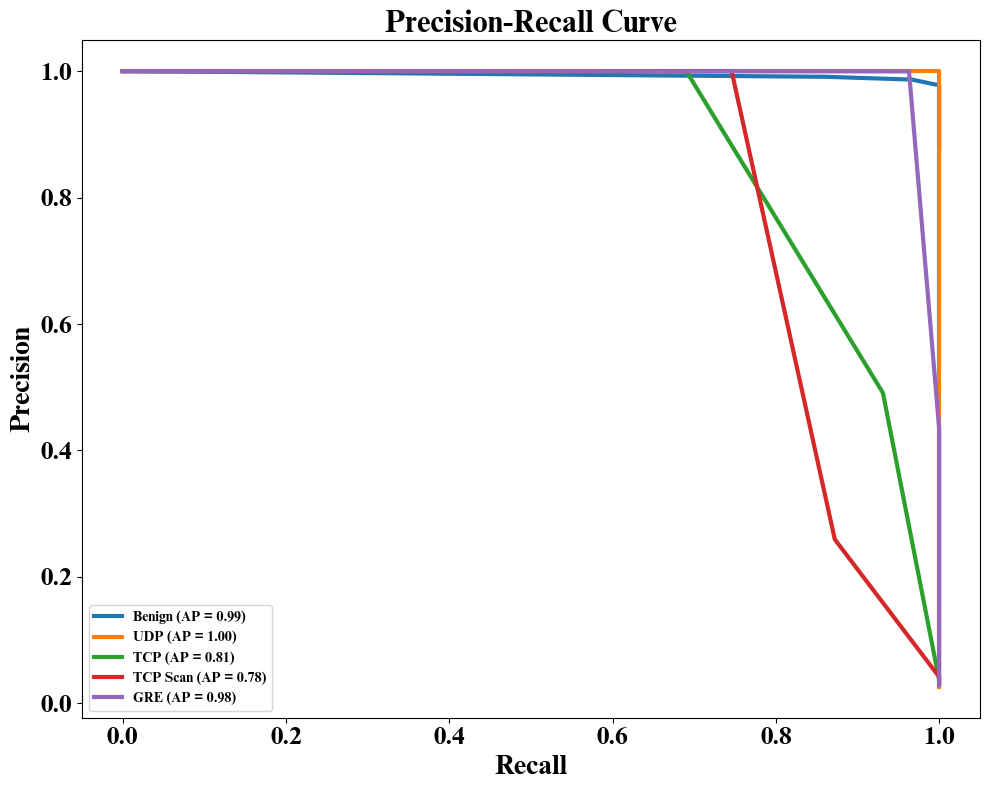

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize


font_path = "/content/times new roman bold.ttf"
prop = fm.FontProperties(fname=font_path)


y_prob = model.predict_proba(X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


class_names = [
    "Benign",
    "UDP",
    "TCP",
    "TCP Scan",
    "GRE"
]

plt.figure(figsize=(10,8))


for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    ap_score = average_precision_score(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        linewidth=3,
        label=f"{class_names[i]} (AP = {ap_score:.2f})"
    )


plt.title("Precision-Recall Curve",
          fontproperties=prop,
          fontsize=22)

plt.xlabel("Recall",
           fontproperties=prop,
           fontsize=20)

plt.ylabel("Precision",
           fontproperties=prop,
           fontsize=20)


ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(18)

for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(18)


plt.legend(
    prop=prop,
    fontsize=18,
    loc="lower left",
    frameon=True
)

plt.tight_layout()
plt.show()

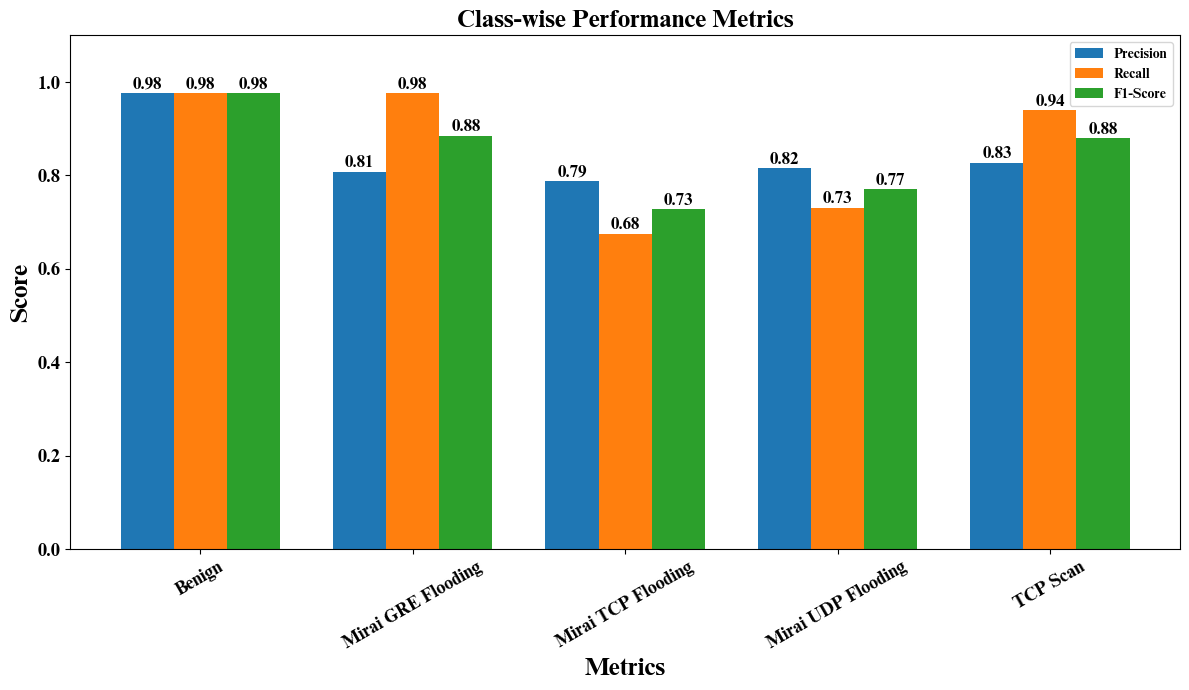

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


prop = fm.FontProperties(fname=font_path)


report = classification_report(y_test, y_pred_modified, output_dict=True)

class_labels_encoded = [k for k in report.keys()
                        if k not in ('accuracy','macro avg','weighted avg')]

class_names = label_encoder.inverse_transform(
    [int(i) for i in class_labels_encoded]
)

precision_vals = [report[c]['precision'] for c in class_labels_encoded]
recall_vals    = [report[c]['recall'] for c in class_labels_encoded]
f1_vals        = [report[c]['f1-score'] for c in class_labels_encoded]

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12,7))

b1 = ax.bar(x-width, precision_vals, width, label="Precision")
b2 = ax.bar(x, recall_vals, width, label="Recall")
b3 = ax.bar(x+width, f1_vals, width, label="F1-Score")


for bars in [b1,b2,b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f"{bar.get_height():.2f}",
                ha='center',
                fontsize=12,
                fontproperties=prop)


ax.set_xticks(x)
ax.set_xticklabels(class_names, fontproperties=prop, rotation=30, fontsize=13)


for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(13)


ax.set_title("Class-wise Performance Metrics",
             fontproperties=prop, fontsize=18)
ax.set_ylabel("Score", fontproperties=prop, fontsize=18)
ax.set_xlabel("Metrics", fontproperties=prop, fontsize=18)
ax.legend(prop=prop)

ax.set_ylim(0,1.1)

plt.tight_layout()
plt.show()

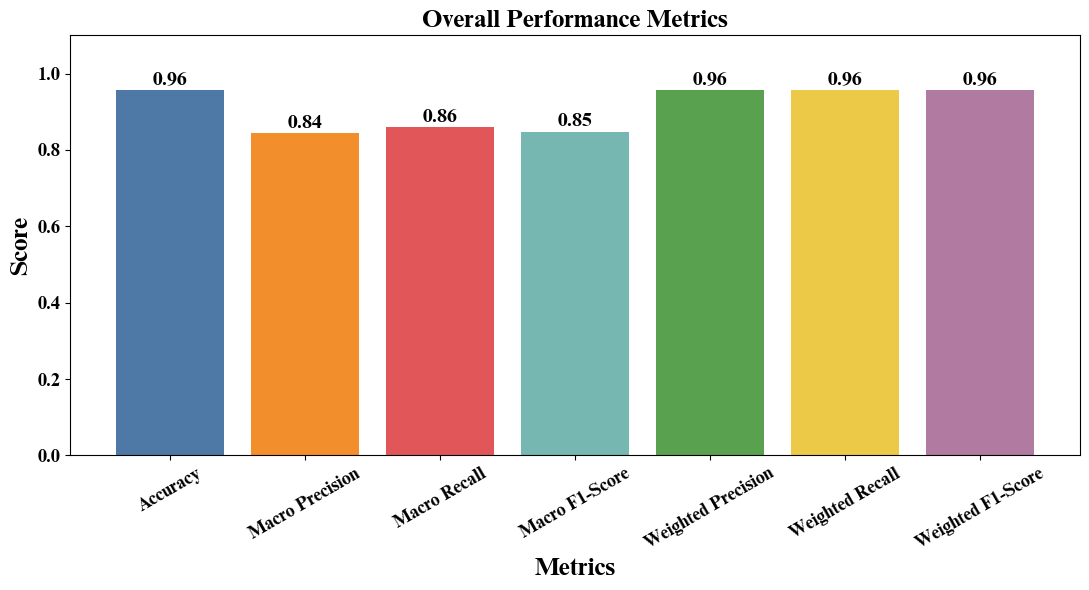


Overall Performance Metrics:

Accuracy: 0.9564
Macro Precision: 0.8431
Macro Recall: 0.8593
Macro F1-Score: 0.8476
Weighted Precision: 0.9564
Weighted Recall: 0.9564
Weighted F1-Score: 0.9559


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np


font_path = "/content/times new roman bold.ttf"
prop = fm.FontProperties(fname=font_path)


accuracy = accuracy_score(y_test, y_pred_modified)

macro_precision = precision_score(y_test, y_pred_modified, average='macro')
macro_recall    = recall_score(y_test, y_pred_modified, average='macro')
macro_f1        = f1_score(y_test, y_pred_modified, average='macro')

weighted_precision = precision_score(y_test, y_pred_modified, average='weighted')
weighted_recall    = recall_score(y_test, y_pred_modified, average='weighted')
weighted_f1        = f1_score(y_test, y_pred_modified, average='weighted')

metric_names = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1-Score",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1-Score"
]

metric_values = [
    accuracy,
    macro_precision,
    macro_recall,
    macro_f1,
    weighted_precision,
    weighted_recall,
    weighted_f1
]


colors = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#EDC948",
    "#B07AA1"
]


fig, ax = plt.subplots(figsize=(11,6))

bars = ax.bar(metric_names, metric_values, color=colors)


for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.015,
            f"{bar.get_height():.2f}",
            ha='center',
            fontsize=14,
            fontproperties=prop)


ax.set_xticks(np.arange(len(metric_names)))
ax.set_xticklabels(metric_names, rotation=30,
                   fontproperties=prop, fontsize=13)

for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(13)

ax.set_ylim(0,1.1)

ax.set_title("Overall Performance Metrics",
             fontproperties=prop, fontsize=18)
ax.set_ylabel("Score", fontproperties=prop, fontsize=18)
ax.set_xlabel("Metrics", fontproperties=prop, fontsize=18)
plt.tight_layout()
plt.show()



print("\nOverall Performance Metrics:\n")
for name, value in zip(metric_names, metric_values):
    print(f"{name}: {value:.4f}")